In [ ]:
# Environment setup
# Use %pip so installs target the active Jupyter kernel.
# If Kaggle/your environment already has these packages, this cell is quick to skip/re-run.

%pip install -q ultralytics sahi ensemble-boxes opencv-python-headless


In [11]:
from pathlib import Path
import configparser
import shutil
import random
import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)


def find_project_root(start=None):
    """Find the project root from a notebook launched at root or below it."""
    start = Path(start or Path.cwd()).resolve()
    marker_sets = [
        ('data', 'notebooks', 'outputs'),
        ('data', 'outputs'),
        ('detect_player', 'tracking'),  # legacy layout fallback
    ]

    for candidate in [start, *start.parents]:
        for markers in marker_sets:
            if all((candidate / marker).exists() for marker in markers):
                return candidate
    return start


def resolve_raw_train_dir(project_root: Path):
    """Resolve SoccerNet tracking/train for the new layout, legacy local layout, and Kaggle."""
    checked = []
    cwd = Path.cwd().resolve()
    candidates = [
        project_root / 'data' / 'raw' / 'tracking' / 'train',
        project_root / 'tracking' / 'train',
        project_root / 'SoccerNet' / 'data' / 'raw' / 'tracking' / 'train',
        project_root / 'SoccerNet' / 'tracking' / 'train',
        cwd / 'data' / 'raw' / 'tracking' / 'train',
        cwd / 'tracking' / 'train',
        cwd.parent / 'data' / 'raw' / 'tracking' / 'train',
        cwd.parent / 'tracking' / 'train',
    ]

    kaggle_input = Path('/', 'kaggle', 'input')
    if kaggle_input.exists():
        for pattern in (
            '*/data/raw/tracking/train',
            '*/tracking/train',
            '*/SoccerNet/data/raw/tracking/train',
            '*/SoccerNet/tracking/train',
            '*/soccernet-tracking/train',
            '*/*/data/raw/tracking/train',
            '*/*/tracking/train',
            '*/*/soccernet-tracking/train',
        ):
            candidates.extend(kaggle_input.glob(pattern))

    for candidate in candidates:
        candidate = candidate.resolve()
        checked.append(candidate)
        if candidate.exists() and any(candidate.iterdir()):
            return candidate

    checked_text = '\n'.join(f'  - {p}' for p in checked)
    raise FileNotFoundError(
        'Could not find SoccerNet tracking train data. Checked:\n' + checked_text +
        '\nExpected a folder like data/raw/tracking/train/SNMOT-060/img1.'
    )


KAGGLE_WORKING = Path('/', 'kaggle', 'working')
IS_KAGGLE = KAGGLE_WORKING.exists()
PROJECT_ROOT = find_project_root()

DATA_DIR = KAGGLE_WORKING / 'data' if IS_KAGGLE else PROJECT_ROOT / 'data'
RAW_TRAIN_DIR = resolve_raw_train_dir(PROJECT_ROOT)
FULLFRAME_YOLO_DIR = DATA_DIR / 'yolo' / 'fullframe'
PATCH_YOLO_DIR = DATA_DIR / 'yolo' / 'patches'
OUTPUT_DIR = KAGGLE_WORKING / 'outputs' / 'detect_player' if IS_KAGGLE else PROJECT_ROOT / 'outputs' / 'detect_player'
RUNS_DIR = OUTPUT_DIR / 'runs'
INFER_DIR = OUTPUT_DIR / 'infer'
PRETRAINED_MODEL_DIR = PROJECT_ROOT / 'models' / 'pretrained'

FULLFRAME_DATA_YAML = FULLFRAME_YOLO_DIR / 'data.yaml'
PATCH_DATA_YAML = PATCH_YOLO_DIR / 'data.yaml'
FULLFRAME_BEST_MODEL_PATH = RUNS_DIR / 'E1_yolo_fullframe_img960' / 'weights' / 'best.pt'
PATCH_BEST_MODEL_PATH = RUNS_DIR / 'E4_yolo_patch_finetune' / 'weights' / 'best.pt'
yaml_path = FULLFRAME_DATA_YAML
patch_yaml = PATCH_DATA_YAML
best_model_path = FULLFRAME_BEST_MODEL_PATH
patch_best_model_path = PATCH_BEST_MODEL_PATH if PATCH_BEST_MODEL_PATH.exists() else None

for path in [DATA_DIR, OUTPUT_DIR, RUNS_DIR, INFER_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Detect player extension classes. Keep ball detection separate from this notebook.
CLASS_NAMES = ['player', 'goalkeeper', 'referee']
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
INCLUDE_BALL = False

if INCLUDE_BALL and 'ball' not in CLASS_TO_ID:
    CLASS_TO_ID['ball'] = len(CLASS_TO_ID)
    CLASS_NAMES.append('ball')

print('Project root:', PROJECT_ROOT)
print('Raw train dir:', RAW_TRAIN_DIR)
print('Data dir:', DATA_DIR)
print('Full-frame YOLO dir:', FULLFRAME_YOLO_DIR)
print('Patch YOLO dir:', PATCH_YOLO_DIR)
print('Output dir:', OUTPUT_DIR)
print('Runs dir:', RUNS_DIR)
print('Infer dir:', INFER_DIR)
print('Pretrained model dir:', PRETRAINED_MODEL_DIR)
print('Classes:', CLASS_NAMES)


def select_training_device():
    """Use CUDA when the active Jupyter kernel has a CUDA-enabled PyTorch build."""
    try:
        import torch
    except ImportError:
        print('PyTorch is not installed in this kernel; YOLO will install/use its default environment.')
        return 'cpu'

    print('Torch:', torch.__version__)
    print('Torch CUDA build:', torch.version.cuda)
    print('CUDA available to torch:', torch.cuda.is_available())
    print('CUDA device count:', torch.cuda.device_count())

    if torch.cuda.is_available() and torch.cuda.device_count() > 0:
        device_name = torch.cuda.get_device_name(0)
        print('Using GPU:', device_name)
        return 'cuda:0'

    print('GPU is visible to Windows, but not to this Python kernel. Falling back to CPU.')
    print('Install a CUDA-enabled PyTorch build in this exact Jupyter kernel to train on GPU.')
    return 'cpu'


TRAIN_DEVICE = select_training_device()


Project root: C:\Users\CPU13374\Downloads\SoccerNet
Raw train dir: C:\Users\CPU13374\Downloads\SoccerNet\data\raw\tracking\train
Data dir: C:\Users\CPU13374\Downloads\SoccerNet\data
Full-frame YOLO dir: C:\Users\CPU13374\Downloads\SoccerNet\data\yolo\fullframe
Patch YOLO dir: C:\Users\CPU13374\Downloads\SoccerNet\data\yolo\patches
Output dir: C:\Users\CPU13374\Downloads\SoccerNet\outputs\detect_player
Runs dir: C:\Users\CPU13374\Downloads\SoccerNet\outputs\detect_player\runs
Infer dir: C:\Users\CPU13374\Downloads\SoccerNet\outputs\detect_player\infer
Pretrained model dir: C:\Users\CPU13374\Downloads\SoccerNet\models\pretrained
Classes: ['player', 'goalkeeper', 'referee']
Torch: 2.11.0+cu128
Torch CUDA build: 12.8
CUDA available to torch: True
CUDA device count: 1
Using GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
def find_sequence_dirs(raw_train_dir: Path):
    seqs = []
    for p in sorted(raw_train_dir.iterdir()):
        if not p.is_dir():
            continue
        if (p / 'img1').exists() and (p / 'gt' / 'gt.txt').exists():
            seqs.append(p)
    return seqs


def read_track_id_to_class(seq_dir: Path):
    """Read gameinfo.ini/seqinfo.ini and return MOT track_id -> class_name."""
    info_path = seq_dir / 'gameinfo.ini'
    if not info_path.exists():
        info_path = seq_dir / 'seqinfo.ini'

    parser = configparser.ConfigParser(strict=False)
    parser.optionxform = str
    parser.read(info_path)

    section = 'Sequence'
    mapping = {}
    if section not in parser:
        return mapping

    for key, value in parser[section].items():
        if not key.startswith('trackletID_'):
            continue
        track_id = int(key.replace('trackletID_', ''))
        desc = value.split(';')[0].strip().lower()

        if 'referee' in desc:
            cls = 'referee'
        elif 'goalkeeper' in desc or 'goalkeepers' in desc:
            cls = 'goalkeeper'
        elif 'player' in desc:
            cls = 'player'
        elif 'ball' in desc:
            cls = 'ball'
        else:
            cls = None

        if cls in CLASS_TO_ID:
            mapping[track_id] = cls
    return mapping


def read_image_size(image_path: Path):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f'Cannot read image: {image_path}')
    h, w = img.shape[:2]
    return w, h


def mot_box_to_yolo(x, y, bw, bh, img_w, img_h):
    # MOT bbox is top-left x,y,width,height in pixels.
    x1 = max(0.0, float(x))
    y1 = max(0.0, float(y))
    x2 = min(float(img_w), float(x) + float(bw))
    y2 = min(float(img_h), float(y) + float(bh))

    clipped_w = x2 - x1
    clipped_h = y2 - y1
    if clipped_w <= 1 or clipped_h <= 1:
        return None

    xc = (x1 + x2) / 2 / img_w
    yc = (y1 + y2) / 2 / img_h
    wn = clipped_w / img_w
    hn = clipped_h / img_h
    return xc, yc, wn, hn

In [3]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm


def process_one_frame(args):
    seq_dir, frame_id, frame_df, split, seq_name, track_to_class = args

    img_name = f'{int(frame_id):06d}.jpg'
    src_img = seq_dir / 'img1' / img_name
    if not src_img.exists():
        return []

    dst_stem = f'{seq_name}_{int(frame_id):06d}'
    dst_img = FULLFRAME_YOLO_DIR / 'images' / split / f'{dst_stem}.jpg'
    dst_label = FULLFRAME_YOLO_DIR / 'labels' / split / f'{dst_stem}.txt'

    shutil.copy2(src_img, dst_img)

    img_w, img_h = read_image_size(src_img)
    label_lines = []
    rows = []

    for r in frame_df.itertuples(index=False):
        track_id = int(r.track_id)
        cls_name = track_to_class.get(track_id)

        if cls_name is None:
            continue

        box = mot_box_to_yolo(r.x, r.y, r.w, r.h, img_w, img_h)
        if box is None:
            continue

        cls_id = CLASS_TO_ID[cls_name]
        xc, yc, wn, hn = box

        label_lines.append(
            f'{cls_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}'
        )

        rows.append({
            'split': split,
            'sequence': seq_name,
            'frame': int(frame_id),
            'class': cls_name,
            'track_id': track_id,
            'image': str(dst_img)
        })

    dst_label.write_text('\n'.join(label_lines), encoding='utf-8')
    return rows


In [4]:
from tqdm import tqdm


def reset_yolo_dir():
    if FULLFRAME_YOLO_DIR.exists():
        shutil.rmtree(FULLFRAME_YOLO_DIR)
    for split in ['train', 'val']:
        (FULLFRAME_YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
        (FULLFRAME_YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)


def convert_mot_dataset_to_yolo_parallel(
    raw_train_dir: Path,
    val_ratio=0.2,
    split_by='sequence',
    max_workers=8
):
    reset_yolo_dir()

    seq_dirs = find_sequence_dirs(raw_train_dir)
    if not seq_dirs:
        raise FileNotFoundError(f'No valid sequence dirs found inside {raw_train_dir}')

    if split_by == 'sequence' and len(seq_dirs) >= 5:
        random.shuffle(seq_dirs)
        n_val = max(1, int(len(seq_dirs) * val_ratio))
        val_seqs = set(seq_dirs[:n_val])
    else:
        val_seqs = set()
        split_by = 'frame'

    tasks = []

    for seq_dir in seq_dirs:
        seq_name = seq_dir.name
        track_to_class = read_track_id_to_class(seq_dir)

        gt_path = seq_dir / 'gt' / 'gt.txt'
        gt = pd.read_csv(gt_path, header=None)
        gt.columns = ['frame', 'track_id', 'x', 'y', 'w', 'h', 'mark', 'c1', 'c2', 'c3'][:gt.shape[1]]

        for frame_id, frame_df in gt.groupby('frame'):
            if split_by == 'sequence':
                split = 'val' if seq_dir in val_seqs else 'train'
            else:
                split = 'val' if int(frame_id) % int(1 / val_ratio) == 0 else 'train'

            tasks.append((seq_dir, frame_id, frame_df, split, seq_name, track_to_class))

    rows = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_one_frame, task) for task in tasks]

        for future in tqdm(as_completed(futures), total=len(futures)):
            rows.extend(future.result())

    data_yaml = {
        'path': str(FULLFRAME_YOLO_DIR.resolve()),
        'train': 'images/train',
        'val': 'images/val',
        'names': {i: name for i, name in enumerate(CLASS_NAMES)},
    }

    yaml_path = FULLFRAME_YOLO_DIR / 'data.yaml'
    yaml_path.write_text(yaml.safe_dump(data_yaml, sort_keys=False), encoding='utf-8')

    df = pd.DataFrame(rows)
    return yaml_path, df


In [5]:
yaml_path, label_df = convert_mot_dataset_to_yolo_parallel(
    RAW_TRAIN_DIR,
    val_ratio=0.2,
    split_by='sequence',
    max_workers=8
)

100%|██████████| 42750/42750 [01:20<00:00, 531.64it/s]


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

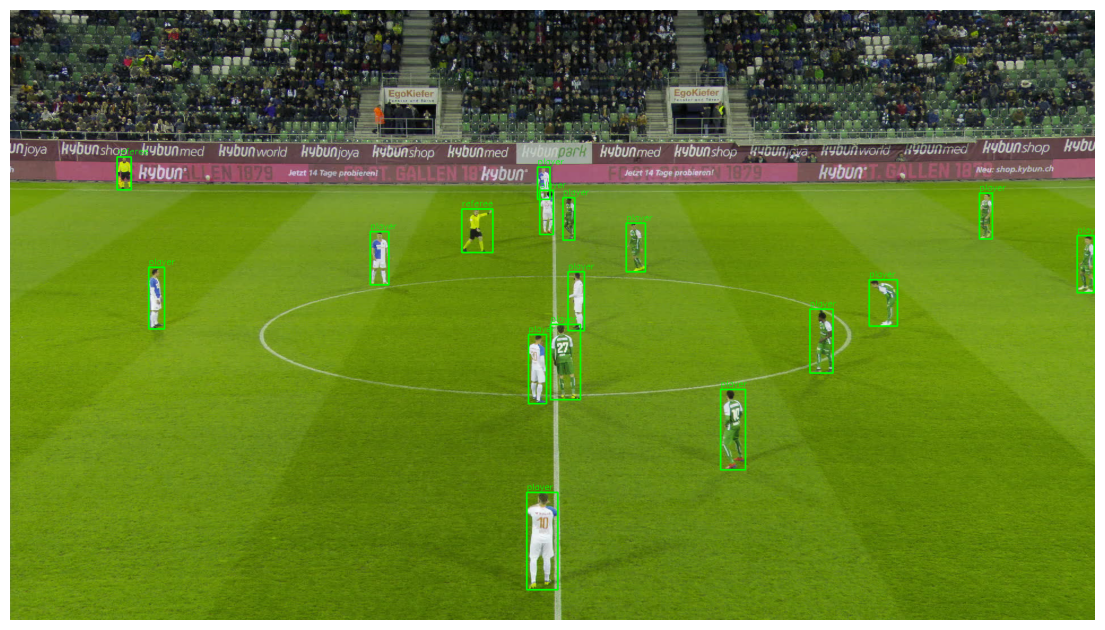

In [6]:
# Visual sanity check mot vai label YOLO

def draw_yolo_labels(image_path, label_path, names):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if Path(label_path).exists():
        for line in Path(label_path).read_text().splitlines():
            cls, xc, yc, bw, bh = line.split()
            cls = int(cls)
            xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, names[cls], (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return img

sample_img = next((FULLFRAME_YOLO_DIR / 'images' / 'train').glob('*.jpg'))
sample_lbl = FULLFRAME_YOLO_DIR / 'labels' / 'train' / f'{sample_img.stem}.txt'
plt.figure(figsize=(14, 8))
plt.imshow(draw_yolo_labels(sample_img, sample_lbl, CLASS_NAMES))
plt.axis('off')


# Train E1/E2: YOLO full-frame / high-res
# imgsz=960 hoặc 1280 thường hợp soccer hơn 640, nhưng tốn VRAM hơn. Nếu Kaggle bị OOM, giảm batch hoặc imgsz.

In [ ]:
from ultralytics import YOLO

# Chon model tuy VRAM: yolov8n.pt nhanh, yolov8s.pt/m.pt tot hon.
BASE_MODEL_PATH = PRETRAINED_MODEL_DIR / 'yolov8n.pt'
BASE_MODEL = str(BASE_MODEL_PATH) if BASE_MODEL_PATH.exists() else 'yolov8n.pt'

model = YOLO(BASE_MODEL)
results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=960,
    batch=16,
    workers=8,
    device=TRAIN_DEVICE,
    project=str(RUNS_DIR),
    name='E1_yolo_fullframe_img960',
    patience=10,
    close_mosaic=10,
    mosaic=1.0,
    mixup=0.05,
    copy_paste=0.10,
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
)

best_model_path = Path(results.save_dir) / 'weights' / 'best.pt'
print('Best model:', best_model_path)


In [ ]:
# Validate nhanh
best_model = YOLO(str(best_model_path))
metrics = best_model.val(data=str(yaml_path), imgsz=960, conf=0.001, iou=0.6, device=TRAIN_DEVICE)
print(metrics)

E4 tùy chọn: tạo patch dataset để slicing-aided fine-tuning
Cell này tạo dataset patch 640x640 overlap 25%. Nó giữ object nếu phần bbox còn nằm trong patch >= 40% diện tích bbox gốc. Sau đó có thể train/fine-tune YOLO trên patch dataset.

In [8]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from tqdm import tqdm
import shutil
import cv2
import yaml
import pandas as pd


def yolo_line_to_xyxy(line, img_w, img_h):
    cls, xc, yc, bw, bh = line.split()
    cls = int(cls)
    xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

    x1 = (xc - bw / 2) * img_w
    y1 = (yc - bh / 2) * img_h
    x2 = (xc + bw / 2) * img_w
    y2 = (yc + bh / 2) * img_h

    return cls, x1, y1, x2, y2


def xyxy_to_yolo(cls, x1, y1, x2, y2, patch_w, patch_h):
    xc = (x1 + x2) / 2 / patch_w
    yc = (y1 + y2) / 2 / patch_h
    bw = (x2 - x1) / patch_w
    bh = (y2 - y1) / patch_h

    return f'{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}'


def process_one_image_patch_task(args):
    img_path, lbl_path, split, out_dir, patch_size, overlap, min_visible = args

    img = cv2.imread(str(img_path))
    if img is None:
        return []

    h, w = img.shape[:2]

    boxes = []
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            if line.strip():
                boxes.append(yolo_line_to_xyxy(line, w, h))

    stride = int(patch_size * (1 - overlap))

    xs = list(range(0, max(1, w - patch_size + 1), stride))
    ys = list(range(0, max(1, h - patch_size + 1), stride))

    if xs[-1] != max(0, w - patch_size):
        xs.append(max(0, w - patch_size))

    if ys[-1] != max(0, h - patch_size):
        ys.append(max(0, h - patch_size))

    stats = []

    for y0 in ys:
        for x0 in xs:
            x1p, y1p = x0, y0
            x2p, y2p = min(w, x0 + patch_size), min(h, y0 + patch_size)

            patch = img[y1p:y2p, x1p:x2p]
            ph, pw = patch.shape[:2]

            patch_labels = []

            for cls, bx1, by1, bx2, by2 in boxes:
                ix1, iy1 = max(bx1, x1p), max(by1, y1p)
                ix2, iy2 = min(bx2, x2p), min(by2, y2p)

                inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
                area = max(1, (bx2 - bx1) * (by2 - by1))

                if inter / area < min_visible:
                    continue

                patch_labels.append(
                    xyxy_to_yolo(
                        cls,
                        ix1 - x1p,
                        iy1 - y1p,
                        ix2 - x1p,
                        iy2 - y1p,
                        pw,
                        ph
                    )
                )

            if not patch_labels:
                continue

            out_stem = f'{img_path.stem}_x{x0}_y{y0}'
            out_img = out_dir / 'images' / split / f'{out_stem}.jpg'
            out_lbl = out_dir / 'labels' / split / f'{out_stem}.txt'

            cv2.imwrite(str(out_img), patch)
            out_lbl.write_text('\n'.join(patch_labels), encoding='utf-8')

            stats.append({
                'split': split,
                'patch': str(out_img),
                'n_labels': len(patch_labels)
            })

    return stats


def create_patch_dataset_parallel(
    src_yolo_dir,
    out_dir,
    patch_size=640,
    overlap=0.25,
    min_visible=0.40,
    max_workers=8
):
    src_yolo_dir = Path(src_yolo_dir)
    out_dir = Path(out_dir)

    if out_dir.exists():
        shutil.rmtree(out_dir)

    for split in ['train', 'val']:
        (out_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
        (out_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

    tasks = []

    for split in ['train', 'val']:
        img_dir = src_yolo_dir / 'images' / split
        lbl_dir = src_yolo_dir / 'labels' / split

        for img_path in sorted(img_dir.glob('*.jpg')):
            lbl_path = lbl_dir / f'{img_path.stem}.txt'

            tasks.append((
                img_path,
                lbl_path,
                split,
                out_dir,
                patch_size,
                overlap,
                min_visible
            ))

    stats = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_one_image_patch_task, task) for task in tasks]

        for future in tqdm(as_completed(futures), total=len(futures)):
            stats.extend(future.result())

    patch_yaml = out_dir / 'data.yaml'
    patch_yaml.write_text(
        yaml.safe_dump({
            'path': str(out_dir.resolve()),
            'train': 'images/train',
            'val': 'images/val',
            'names': {i: name for i, name in enumerate(CLASS_NAMES)},
        }, sort_keys=False),
        encoding='utf-8'
    )

    return patch_yaml, pd.DataFrame(stats)


In [9]:
# patch_yaml, patch_stats = create_patch_dataset_parallel(
#     FULLFRAME_YOLO_DIR,
#     PATCH_YOLO_DIR,
#     patch_size=640,
#     overlap=0.25,
#     min_visible=0.40,
#     max_workers=8
# )

# print('Patch yaml:', patch_yaml)

# display(
#     patch_stats.groupby('split').agg(
#         patches=('patch', 'count'),
#         labels=('n_labels', 'sum')
#     )
# )


In [12]:
# # Fine-tune tu model full-frame tren patch dataset
from ultralytics import YOLO

# # Chon model tuy VRAM: yolov8n.pt nhanh, yolov8s.pt/m.pt tot hon.
# BASE_MODEL = 'yolov8n.pt'
fullframe_checkpoint_path = FULLFRAME_BEST_MODEL_PATH
patch_checkpoint_path = PATCH_BEST_MODEL_PATH

if not fullframe_checkpoint_path.exists():
    raise FileNotFoundError(f'Missing full-frame checkpoint: {fullframe_checkpoint_path}')

best_model_path = fullframe_checkpoint_path
patch_best_model_path = patch_checkpoint_path if patch_checkpoint_path.exists() else None
print('Full-frame checkpoint:', best_model_path)
if patch_best_model_path:
    print('Patch checkpoint:', patch_best_model_path)
else:
    print('Patch checkpoint not found yet:', patch_checkpoint_path)

# patch_model = YOLO(str(best_model_path))
# patch_results = patch_model.train(
#     data=str(patch_yaml),
#     epochs=15,
#     imgsz=640,
#     batch=98,
#     workers=8,
#     device=TRAIN_DEVICE,
#     project=str(RUNS_DIR),
#     name='E4_yolo_patch_finetune',
#     patience=5,
#     close_mosaic=5,
# )

# patch_best_model_path = Path(patch_results.save_dir) / 'weights' / 'best.pt'
# print('Patch best model:', patch_best_model_path)


Full-frame checkpoint: C:\Users\CPU13374\Downloads\SoccerNet\outputs\detect_player\runs\E1_yolo_fullframe_img960\weights\best.pt
Patch checkpoint not found yet: C:\Users\CPU13374\Downloads\SoccerNet\outputs\detect_player\runs\E4_yolo_patch_finetune\weights\best.pt


Infer thử full-frame


image 1/1 C:\Users\CPU13374\Downloads\SoccerNet\data\yolo\fullframe\images\val\SNMOT-069_000001.jpg: 544x960 17 players, 2 referees, 30.8ms
Speed: 2.5ms preprocess, 30.8ms inference, 12.0ms postprocess per image at shape (1, 3, 544, 960)
Results saved to C:\Users\CPU13374\Downloads\SoccerNet\outputs\detect_player\infer\fullframe-3


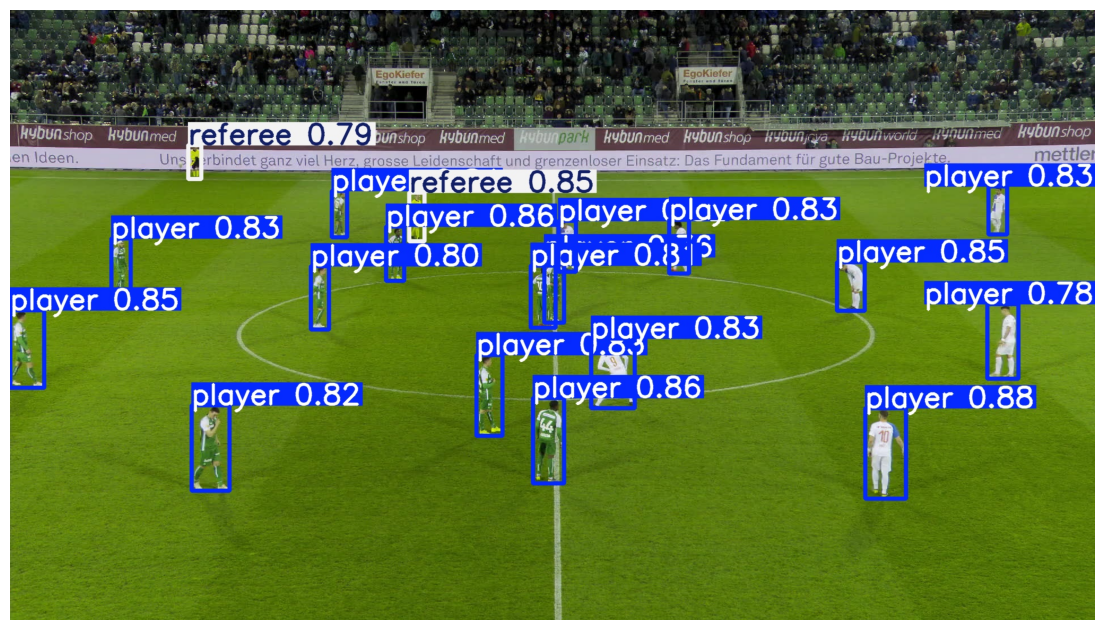

In [13]:
INFER_MODEL_PATH = str(best_model_path)  # doi thanh str(patch_best_model_path) neu muon test model patch
infer_model = YOLO(INFER_MODEL_PATH)

test_img = next((FULLFRAME_YOLO_DIR / 'images' / 'val').glob('*.jpg'))
pred = infer_model.predict(
    source=str(test_img),
    imgsz=960,
    conf=0.25,
    iou=0.6,
    save=True,
    project=str(INFER_DIR),
    name='fullframe',
)

result_img = Path(pred[0].save_dir) / test_img.name
plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(cv2.imread(str(result_img)), cv2.COLOR_BGR2RGB))
plt.axis('off');


Infer thử SAHI-like sliced inference
Dùng get_sliced_prediction của SAHI để chia frame lớn thành nhiều tile, detect trên từng tile, rồi merge box lại. Trick này thường tăng recall với player nhỏ/xa camera, đổi lại FPS giảm.

Performing prediction on 8 slices.
Number of detections: 34


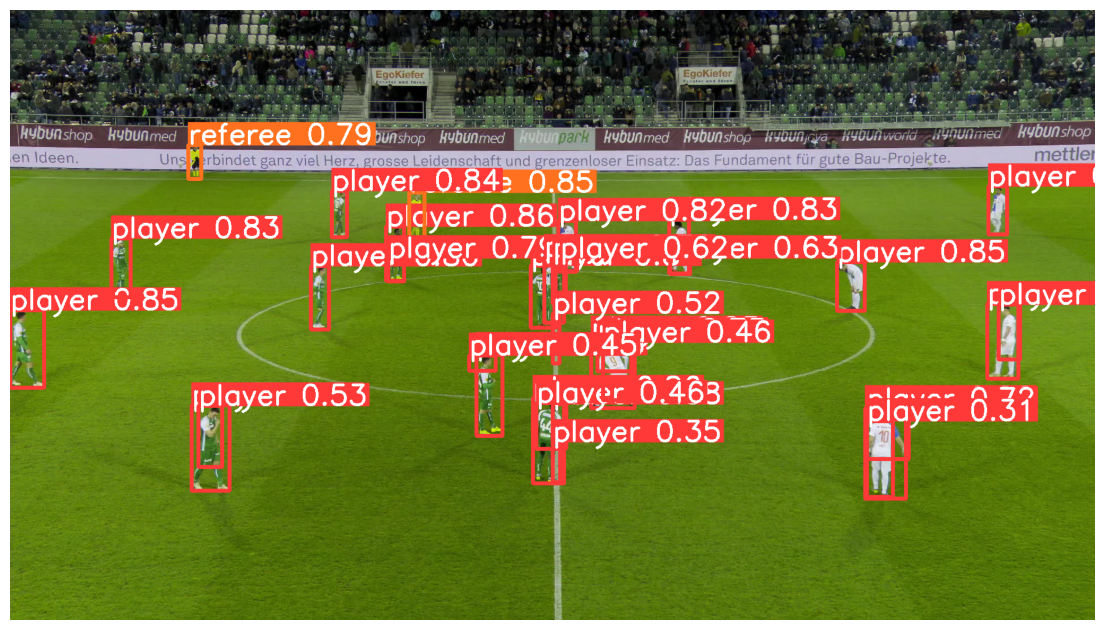

In [ ]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import read_image

detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=INFER_MODEL_PATH,
    confidence_threshold=0.20,
    device=TRAIN_DEVICE,
)

sahi_result = get_sliced_prediction(
    str(test_img),
    detection_model,
    slice_height=640,
    slice_width=640,
    overlap_height_ratio=0.25,
    overlap_width_ratio=0.25,
    postprocess_type='NMS',
    postprocess_match_metric='IOU',
    postprocess_match_threshold=0.55,
)

SAHI_OUT = INFER_DIR / 'sahi'
SAHI_OUT.mkdir(parents=True, exist_ok=True)
sahi_result.export_visuals(export_dir=str(SAHI_OUT), file_name='sahi_result')

plt.figure(figsize=(14, 8))
plt.imshow(read_image(str(SAHI_OUT / 'sahi_result.png')))
plt.axis('off')

print('Number of detections:', len(sahi_result.object_prediction_list))


In [ ]:
CLASS_THRESHOLDS = {
    'player': 0.35,
    'goalkeeper': 0.25,
    'referee': 0.20,
}

def filter_ultralytics_result_by_class_threshold(result, names, thresholds):
    boxes = result.boxes
    keep = []
    for i, (cls_id, conf) in enumerate(zip(boxes.cls.cpu().numpy(), boxes.conf.cpu().numpy())):
        cls_name = names[int(cls_id)]
        if conf >= thresholds.get(cls_name, 0.25):
            keep.append(i)
    return keep

raw_pred = infer_model.predict(str(test_img), imgsz=960, conf=0.05, iou=0.6, verbose=False)[0]
keep_idx = filter_ultralytics_result_by_class_threshold(raw_pred, infer_model.names, CLASS_THRESHOLDS)
print('Raw boxes:', len(raw_pred.boxes), 'Kept boxes:', len(keep_idx))

img = cv2.cvtColor(cv2.imread(str(test_img)), cv2.COLOR_BGR2RGB)
for i in keep_idx:
    xyxy = raw_pred.boxes.xyxy[i].cpu().numpy().astype(int)
    conf = float(raw_pred.boxes.conf[i].cpu().numpy())
    cls_id = int(raw_pred.boxes.cls[i].cpu().numpy())
    name = infer_model.names[cls_id]
    x1, y1, x2, y2 = xyxy
    cv2.rectangle(img, (x1, y1), (x2, y2), (20, 220, 90), 2)
    cv2.putText(img, f'{name} {conf:.2f}', (x1, max(18, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (20, 220, 90), 2)

plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis('off');

## E5 tùy chọn: Tracking-assisted detection bằng ByteTrack
## Ultralytics có thể track trực tiếp trên folder frame hoặc video. Nếu source là folder ảnh img1, output sẽ nằm trong runs/track/....

In [ ]:
# Chay tracking tren mot sequence goc va xuat thang ra video mp4
def get_sequence_fps(seq_dir: Path, default_fps=25):
    for info_name in ('seqinfo.ini', 'gameinfo.ini'):
        info_path = seq_dir / info_name
        if not info_path.exists():
            continue

        parser = configparser.ConfigParser(strict=False)
        parser.optionxform = str
        parser.read(info_path)

        if 'Sequence' not in parser:
            continue

        for key in ('frameRate', 'fps'):
            if key in parser['Sequence']:
                try:
                    return float(parser['Sequence'][key])
                except ValueError:
                    pass

    return default_fps


seq_dirs = find_sequence_dirs(RAW_TRAIN_DIR)
track_seq = seq_dirs[0]
track_source = track_seq / 'img1'
track_fps = get_sequence_fps(track_seq)

track_output_dir = INFER_DIR / 'bytetrack_sequence'
track_output_dir.mkdir(parents=True, exist_ok=True)
track_video_path = track_output_dir / f'{track_seq.name}_bytetrack.mp4'

track_device = TRAIN_DEVICE if 'TRAIN_DEVICE' in globals() else None
track_stream = infer_model.track(
    source=str(track_source),
    imgsz=960,
    conf=0.20,
    iou=0.6,
    tracker='bytetrack.yaml',
    persist=True,
    stream=True,
    save=False,
    device=track_device,
    verbose=False,
)

writer = None
frame_count = 0

for result in track_stream:
    frame = result.plot()

    if writer is None:
        h, w = frame.shape[:2]
        writer = cv2.VideoWriter(
            str(track_video_path),
            cv2.VideoWriter_fourcc(*'mp4v'),
            track_fps,
            (w, h),
        )
        if not writer.isOpened():
            raise RuntimeError(f'Cannot create video writer: {track_video_path}')

    writer.write(frame)
    frame_count += 1

if writer is None:
    raise RuntimeError(f'No frames were processed from: {track_source}')

writer.release()

print('Tracking source:', track_source)
print('Frames written:', frame_count)
print('Tracking video:', track_video_path)

try:
    from IPython.display import Video, display
    display(Video(str(track_video_path), embed=False))
except Exception:
    pass
